# Tutorial on deep learning
Using a neural network to assess vascular age from pulse waves

The material for this workshop has been adapted from supplementary material in this article https://doi.org/10.1093/ehjdh/ztab089.

This tutorial trains a deep learning neural network to classify PPG pulse waves as either "young" or "elderly". 
It uses publicly available, simulated PPG data (described in this article https://doi.org/10.1152/ajpheart.00218.2019).

The Pulse Wave Data Base (PWDB) has been developed by Peter Charlton and is described in this article https://journals.physiology.org/doi/full/10.1152/ajpheart.00218.2019.

The MATLAB code has been adapted in python for the needs of VITAL's first training school.

In [1]:
from IPython.display import display, Image
from utilities.utils_tutorial2 import *
from scipy.io import loadmat

# PPG signals

Photoplethysmogram (PPG) pulse waves differ in shape between young and elderly subjects. Young subjects typically exhibit a second, diastolic peak on the downslope, which disappears with age and is not often present in PPGs from elderly subjects:

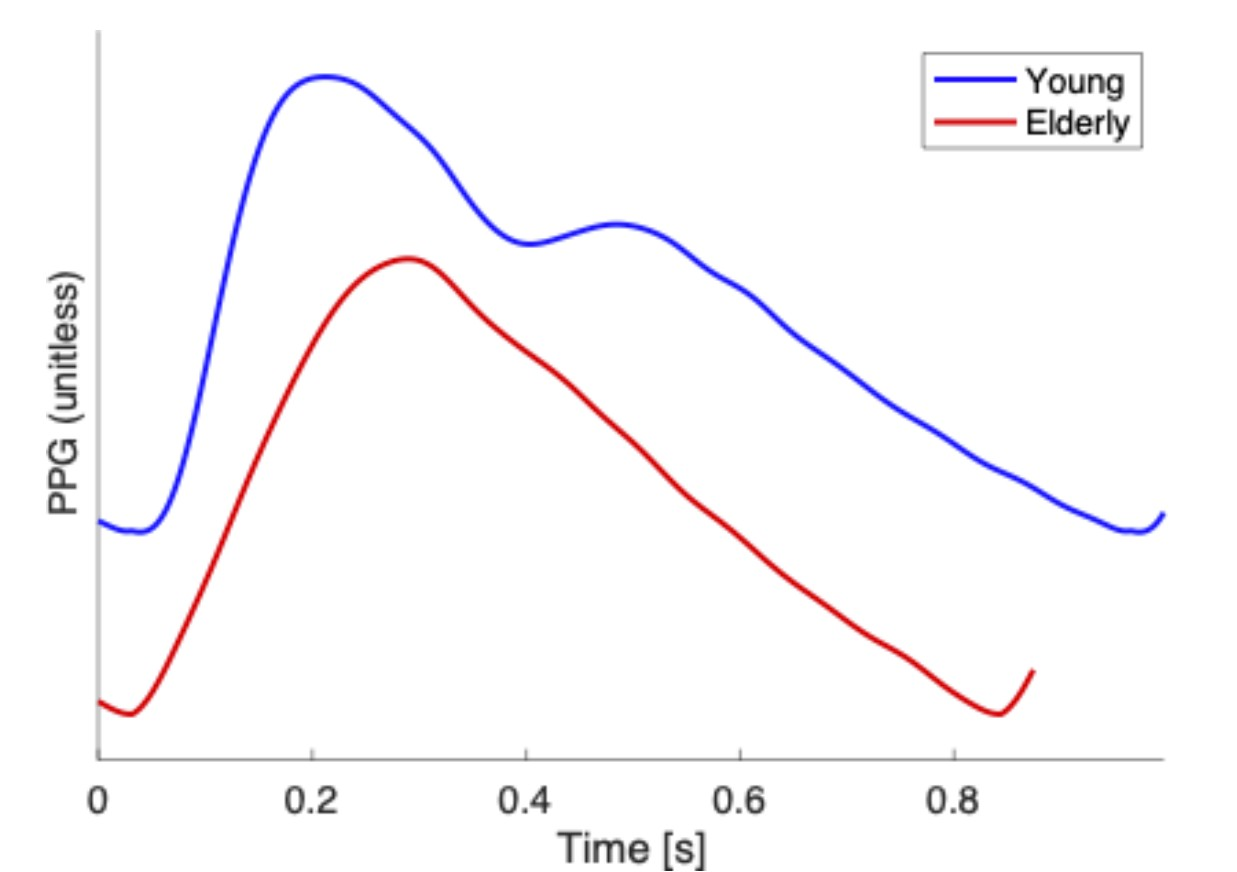

In [2]:
display(Image(filename="ppg_signals.jpg", width=400, height=300))

We first decide whether to classify pulse waves as 'young' or 'elderly' or to predict the exact age of the subject.
This notebook supports **two modes**:
- **Classification:** Categorizing subjects as 'young' or 'elderly'.
- **Regression:** Predicting numerical age.

The mode is stored in a configuration dictionary.

In [3]:
mode = get_config(mode='regression') # choose if regression or classification

Running in regression mode.


# Load the PWDB data

In [4]:
# Load the PWDB data
data = loadmat('data/pwdb_data.mat')
# Access the main data structure
pwdb_data = data['data']

# Step 1: Extract and downsample PPG data 

- Downsampling options:

In [5]:
sampling_rate = 50  # new sampling frequency <- you choose

old_sampling_rate = pwdb_data['waves'][0, 0]['fs'][0, 0].flatten() # initial sampling frequency 500 Hz for PWDB
ds_factor = np.round(old_sampling_rate/sampling_rate) # downsampling factor

print(f"Downsampling from {old_sampling_rate[0]:.0f} Hz to {sampling_rate} Hz with a factor of {int(ds_factor[0])}.")

Downsampling from 500 Hz to 50 Hz with a factor of 10.


- Create the full dataset: load and downsample all PPG signals, along with age, subject_id, plausibility log of all virtual subjects.

In [6]:
ppg_df = load_all_ppg_radial(pwdb_data, old_sampling_rate, sampling_rate)

Loaded and downsampled PPG Radial signals for 4374 subjects (from [500]Hz to 50Hz).


In [7]:
ppg_df.head()

,subject_id,age,pwv_SD,fs,signal_length,ppg_signal,time_vector,plausibility_log
0,0,25,0,50,36,"[0.0, 0.09061194076934695, 0.2735794009870884,...","[0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14,...",True
1,1,35,0,50,42,"[0.0, 0.035735616538486024, 0.1938103863385159...","[0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14,...",True
2,2,45,0,50,40,"[0.0, 0.0507928214908324, 0.23104314731210085,...","[0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14,...",True
3,3,55,0,50,39,"[0.0, 0.05948237176939345, 0.2519162836995045,...","[0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14,...",True
4,4,65,0,50,39,"[0.0, 0.07403593900364962, 0.28028863425708617...","[0.0, 0.02, 0.04, 0.06, 0.08, 0.1, 0.12, 0.14,...",True


# Step 2: Split the dataset
In the standard approach, datasets are split using randomized methods (e.g., sklearn's train_test_split). 
In this tutorial, we follow a simple structured splitting approach: 
    - even-indexed subjects go into the training+validation set, 
    - odd-indexed subjects go into the test set.

We have some further considerations:
- We need to discard implausible subjects, as per the plausibility_log column of the dataframe above.
- In the case of **classification** mode, we retain plausible subjects with the age of 25 (Young) and 75 (Elderly).
- In the case of **regression** mode, we retain the numerical age of all plausible subjects.


In [8]:
train_data, test_data, test_data_for_postprocessing = split_train_test_data(ppg_df, mode="classification") # switch the mode [classification, regression] to obtain different subsets

Training data: 635 subjects (356 young and 279 elderly)
Testing data: 635 subjects (356 young and 279 elderly)


# Inspect the pulse wave data

In [9]:
train_data.head()

,ppg_signal,age
0,"[0.0, 0.09061194076934695, 0.2735794009870884,...",25
1,"[0.0, 0.036045797831908845, 0.1989255081821931...",25
2,"[0.0, 0.03660013866164823, 0.19678519812294745...",25
3,"[0.0, 0.03461638837754049, 0.18488993484070237...",25
4,"[0.0, 0.03712172682529599, 0.20201781094096902...",25


The predictor variable (the PPG) is contained in the column `ppg_signal`. The response variable is contained in the age column (in the case of classification, as categorical vectors of labels 25 and 75 years old). Here is an example of young and elderly PPG pulse waves from the simulated dataset:

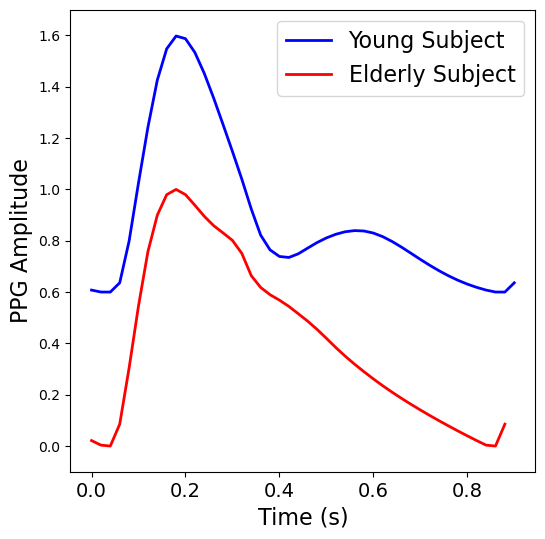

In [10]:
plot_pulse_waves(train_data, sampling_rate=50)

The pulse waves exhibited similar changes with age to those observed in healthy volunteers: most markedly, the diastolic peak disappears with age. 
(see this article for a comparison between pulse waves from young and elderly subjects) #ToDo

# Switch to tabular structure

### Expanding PPG Signals into Tabular Format

Since PPG signals are time-series data stored in a single column (`ppg_signal`), we expand them into a **structured tabular format**. Each time step of the signal is assigned to a **separate column**, allowing for easier preprocessing and integration with machine learning models.

This format

✔ Works well with standard machine learning models (e.g., XGBoost, Random Forest, Linear Models)  
✔ Avoids dealing with lists inside DataFrames  
✔ Enables direct feature engineering and scaling

In the next step, we
- Expand each time-series signal into separate numbered columns.
- Ensure the **age** column remains at the **end** for easy access (`X[:, -1]`).


In [11]:
# Apply function to train and test datasets
train_data_expanded = switch_to_tabular(train_data, column_name="ppg_signal", target_column="age")
test_data_expanded = switch_to_tabular(test_data, column_name="ppg_signal", target_column="age")

print(f"Expanded DataFrame shape: {train_data_expanded.shape} (samples, time_steps + 1)")
train_data_expanded.head()

Expanded DataFrame shape: (635, 50) (samples, time_steps + 1)


,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,age
0,0.0,0.090612,0.273579,0.465087,0.625133,0.750892,0.844558,0.912713,0.960224,0.988812,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25
1,0.0,0.036046,0.198926,0.425461,0.641679,0.825601,0.947625,0.997568,0.987196,0.933485,...,0.007692,0.000089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25
2,0.0,0.036600,0.196785,0.420006,0.635782,0.818329,0.941838,0.996025,0.989916,0.938187,...,0.008910,0.000167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25
3,0.0,0.034616,0.184890,0.407214,0.621976,0.803109,0.930188,0.992207,0.994184,0.947949,...,0.009360,0.000315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25
4,0.0,0.037122,0.202018,0.425445,0.637307,0.815159,0.936759,0.993653,0.993794,0.950640,...,0.009922,0.000253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25


# Step 3: Scale the dataset

In [12]:
X_train, X_test, y_train, y_test, scaler_X, scaler_y = scale_data(train_data_expanded, test_data_expanded)

Data scaled using MinMaxScaler (features and target separately)


In [13]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,0.0,0.804971,0.731271,0.730515,0.714275,0.736935,0.810391,0.890696,0.949423,0.985751,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.275187,0.495687,0.655484,0.737544,0.828814,0.936113,0.996955,0.983720,0.915285,...,0.017520,0.007222,0.000129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,0.280569,0.488933,0.645154,0.729252,0.819870,0.929054,0.995022,0.987178,0.921275,...,0.019379,0.008749,0.000243,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,0.261309,0.451395,0.620933,0.709835,0.801152,0.914843,0.990241,0.992604,0.933707,...,0.021426,0.009314,0.000458,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,0.285633,0.505445,0.655453,0.731396,0.815972,0.922859,0.992053,0.992109,0.937135,...,0.021665,0.010019,0.000369,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- **Pad** shorter sequences with `-1` for uniform shape (this value is then filtered out in the LSTM).

In [14]:
pad_value=-1
X_train=padding(X_train,pad_value)
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
0,0.0,0.804971,0.731271,0.730515,0.714275,0.736935,0.810391,0.890696,0.949423,0.985751,...,-1.000000,-1.000000,-1.000000,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,0.0,0.275187,0.495687,0.655484,0.737544,0.828814,0.936113,0.996955,0.983720,0.915285,...,0.017520,0.007222,0.000129,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,0.0,0.280569,0.488933,0.645154,0.729252,0.819870,0.929054,0.995022,0.987178,0.921275,...,0.019379,0.008749,0.000243,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,0.0,0.261309,0.451395,0.620933,0.709835,0.801152,0.914843,0.990241,0.992604,0.933707,...,0.021426,0.009314,0.000458,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,0.0,0.285633,0.505445,0.655453,0.731396,0.815972,0.922859,0.992053,0.992109,0.937135,...,0.021665,0.010019,0.000369,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0


# Step 4: Defining a neural network
We now define the architecture of the neural network. A long short-term memory (LSTM) recurrent neural network is used, as this is suitable for time series data (in this case, PPG pulse waves).

In [15]:
# Build the model dynamically with proper Masking
ppg_model = build_lstm_model(mode=mode)

# Print model summary
print(f"LSTM Model for {mode.capitalize()} Mode:")
ppg_model.summary()

LSTM Model for Regression Mode:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, None, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, None, 1)        │             4 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,905 (159.79 KB)

 Trainable params: 40,903 (159.78 KB)

 Non-trainable params: 2 (8.00 B)

In [16]:
train_options = get_training_options(train_data, mode=mode)

print(f"Training Options for {mode.capitalize()} Mode:")
print(train_options)

Training Options for Regression Mode:
{'epochs': 100, 'batch_size': 32, 'callbacks': [<keras.src.callbacks.early_stopping.EarlyStopping object at 0x00000218ACC2D990>], 'verbose': 1}


# Step 5: Training the network


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.2519 - mae: 0.3808 - val_loss: 0.7943 - val_mae: 0.8912
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1869 - mae: 0.3676 - val_loss: 0.1641 - val_mae: 0.3935
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0882 - mae: 0.2206 - val_loss: 0.3014 - val_mae: 0.5460
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0899 - mae: 0.2131 - val_loss: 0.1385 - val_mae: 0.3524
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0765 - mae: 0.1942 - val_loss: 0.0817 - val_mae: 0.2613
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0695 - mae: 0.1712 - val_loss: 0.2315 - val_mae: 0.4699
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0723 - mae: 0.1702 - val_loss: 0.1352 - val_mae: 0.3489
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0572 - mae: 0.1482 - val_loss: 0.1582 - val_mae: 0.3770
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - lo

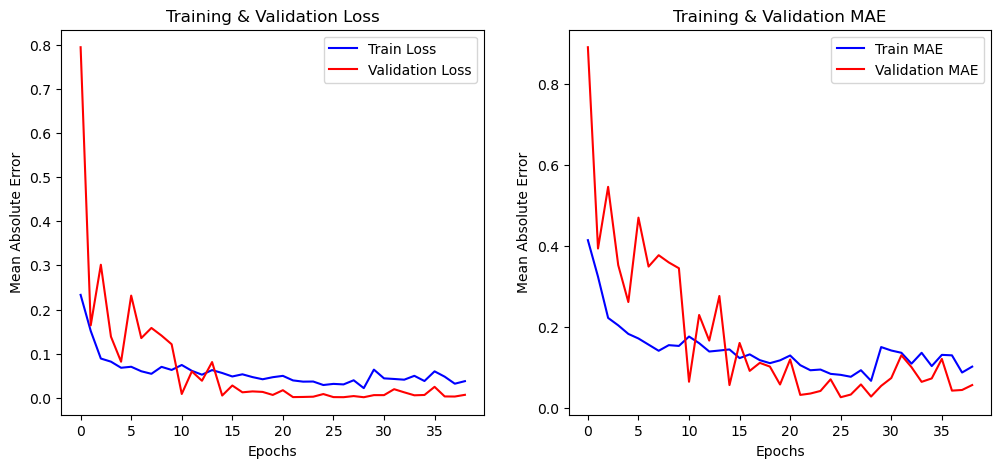

In [17]:
trained_model, training_history = train_lstm_model(ppg_model, train_data, mode=mode)

# Step 6: Assessing performance on the testing data
Use the neural network to classify the subjects in the test dataset as either young or elderly.

In [18]:
YPred = evaluate_model(trained_model, test_data, scaler_y, mode=mode) #ToDo fix
print("Predictions:", YPred)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


UnboundLocalError: local variable 'YPred' referenced before assignment

# Step 7 : Assess the performance of the neural network in classification mode
Calculate the accuracy of classifications (the proportion of classifications which were correct).

In [ ]:
assess_model_performance(YPred, test_data, mode=mode)

Accuracy: 87.4%
Number of correctly classified PPG waves: 555 out of 635
🔹 Number of elderly PPG waves misclassified as young: 0
🔹 Number of young PPG waves misclassified as elderly: 80

📊 Classification Report:
               precision    recall  f1-score   support

       Young       1.00      0.78      0.87       356
     Elderly       0.78      1.00      0.87       279

    accuracy                           0.87       635
   macro avg       0.89      0.89      0.87       635
weighted avg       0.90      0.87      0.87       635


🔹 Confusion Matrix:
 [[276  80]
 [  0 279]]


Step 8: Investigate reasons for misclassifications

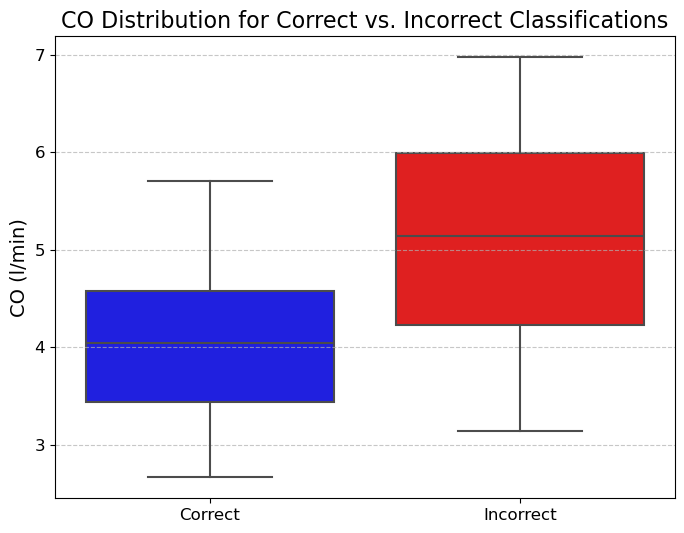

In [ ]:
analyze_classification_errors(YPred, test_data_for_postprocessing, pwdb_data)